In [1]:
import numpy as np

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from catboost import CatBoostRegressor
from typing import Union, Dict, Tuple
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')
# matplotlib inline

#Table of contents #
**Feature description
**

In [3]:
#load data
data = pd.read_parquet('../data/01_raw/bike_data_train.parquet')

In [4]:
data.head(3)

,datetime,season,hr,holiday,weekday,weathersit,temp,hum,windspeed,cnt
0,2011-01-01 00:00:00,1,0,0,6,1,0.24,0.81,0.0,16
1,2011-01-01 01:00:00,1,1,0,6,1,0.22,0.80,0.0,40
2,2011-01-01 02:00:00,1,2,0,6,1,0.22,0.80,0.0,32


* datetime - hourly time + date
* season - 1 = winter, 2 = spring, 3 = summer, 4 = autumn
* hr - hour of the day
* holiday - whether day is considered a holiday
* weathersit
  - 1: Clear & partially cloudy, Partially cloudy
  - 2: Mist + Cloudy
  - 3: Light Snow, Light Rain
  - 4: Heavy Rain, Snow
* temp - temperature in Celsius as decimal
* hum - relative humidity
* windspeed
* cnt - number of total rentals (casual + registered)

In [5]:
data.columns

Index(['datetime', 'season', 'hr', 'holiday', 'weekday', 'weathersit', 'temp',
       'hum', 'windspeed', 'cnt'],
      dtype='str')

In [6]:
data.drop(columns=['datetime'], inplace=True)

# Baseline Model

In [7]:
def compute_metrics(
    y_true: Union[np.ndarray, list],
    y_pred: Union[np.ndarray, list]
) -> Dict[str, float]:
    """
    Compute evaluation metrics between true and predicted values.

    Metrics returned:
    - MAPE: Mean absolute percentage error (in %)
    - MAE: Mean absolute error
    -RMSE: Root mean squared error

    Parameters:
    ----------
    y_true: array-like 
        Ground truth values.
    y_pred: array-like
        Predicted values.

    Returns:
    -------
    dict
        Dictionary with keys 'MAPE', 'MAE', and 'RMSE' and their float values.
    """
    y_true = np.array(y_true).ravel()
    y_pred = np.array(y_pred).ravel()

    mae = float(mean_absolute_error(y_true, y_pred))                
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true + 1e-8)) * 100

    return {
        'MAE': float(round(mae, 2)),
        'RMSE': float(round(rmse, 2)),
        'MAPE': float(round(mape, 2))
    }

In [8]:
def prepare_dataset(
    df: pd.DataFrame,
    train_fraction: float = 0.8
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:
    """
    Splits a DataFrame into training and testing sets for features and target.

    Parameters:
    ----------
    df: pd.DataFrame
        The input DataFrame that must contain a 'target' column.
    train_fracrtion: float, optional (default=0.8)
        The fraction of data to use for training (between 0 and 1).

    Returns:
    -------
    x_train: pd.DataFrame
        training features.
    x_test: pd.DataFrame
        testing features
    y_train: pd.Series
        training target values
    y_test: pd.Series
        testing target values
    """
    feats = [col for col in df if col != 'target']
    x, y = df[feats], df['target']
    train_size = int(train_fraction * df.shape[0])
    x_train, x_test = x[:train_size], x[train_size:]
    y_train, y_test = y[:train_size], y[train_size:]

    return x_train, x_test, y_train, y_test

## Target Definition

In [9]:
df = data.copy()

In [10]:
df['target'] = df['cnt'].shift(-1).ffill()
df.drop(columns=['cnt'], inplace=True)

In [11]:
df.head(3)

,season,hr,holiday,weekday,weathersit,temp,hum,windspeed,target
0,1,0,0,6,1,0.24,0.81,0.0,40.0
1,1,1,0,6,1,0.22,0.80,0.0,32.0
2,1,2,0,6,1,0.22,0.80,0.0,13.0


## Fitting the model

In [12]:
x_train, x_test, y_train, y_test = prepare_dataset(df, train_fraction=0.8)

In [13]:
params = {
    'learning_rate': 0.2,
    'depth': 6,
    'l2_leaf_reg': 1,
    'iterations': 500,
    'loss_function': 'RMSE',
    'verbose': 0
}

np.random.seed(42)
model = CatBoostRegressor(**params, random_seed=42)

#training w early stopping
model.fit(x_train, y_train)

CatBoostRegressor(depth=6, iterations=500, l2_leaf_reg=1, learning_rate=0.2, loss_function='RMSE', random_seed=42, verbose=0)

##Baseline Predictions

In [15]:
y_pred = model.predict(x_test)
compute_metrics(y_test.values, y_pred)

{'MAE': 85.27, 'RMSE': 116.06, 'MAPE': 43.99}

Text(0.5, 1.0, 'Rented Bike Count, 1-h Forecast, Baseline')

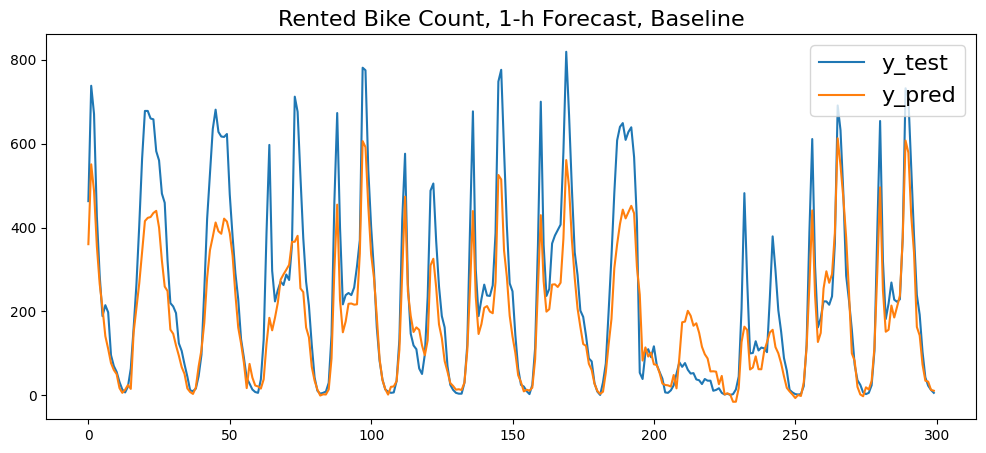

In [17]:
n = 300
plt.figure(figsize=(12, 5))
plt.plot(y_test.values[:n], label='y_test')
plt.plot(y_pred[:n], label='y_pred')
plt.legend(fontsize=16)
plt.title('Rented Bike Count, 1-h Forecast, Baseline', fontsize=16)

We can see from the plot and the computed metrics that the baseline model is not very strong. It fails to capture the spikes in demand accurately and has a high MAPE (43.99%)

## Baseline Model Lag Features
A good idea is to add lagged values of the target because we assume it'll be available by the time we make predictions for the next hour. 

To understand how many lagged features we will need, we compute the autocorrelation for the target

In [19]:
df = data.copy()
df['target'] = df['cnt'].shift(-1).ffill()
df.head(3)

,season,hr,holiday,weekday,weathersit,temp,hum,windspeed,cnt,target
0,1,0,0,6,1,0.24,0.81,0.0,16,40.0
1,1,1,0,6,1,0.22,0.80,0.0,40,32.0
2,1,2,0,6,1,0.22,0.80,0.0,32,13.0


In [20]:
#computing autocorrelation
for lag in range(1, 25):
    print(f"Lag: {lag}: {df['target'].autocorr(lag=lag):.3f}")

Lag: 1: 0.845
Lag: 2: 0.597
Lag: 3: 0.407
Lag: 4: 0.274
Lag: 5: 0.146
Lag: 6: 0.010
Lag: 7: -0.094
Lag: 8: -0.114
Lag: 9: -0.058
Lag: 10: -0.049
Lag: 11: -0.100
Lag: 12: -0.131
Lag: 13: -0.105
Lag: 14: -0.057
Lag: 15: -0.058
Lag: 16: -0.094
Lag: 17: -0.065
Lag: 18: 0.033
Lag: 19: 0.153
Lag: 20: 0.262
Lag: 21: 0.371
Lag: 22: 0.520
Lag: 23: 0.705
Lag: 24: 0.809


We see that the autocorrelation drops off rapidly after the 3rd lag, picking up again at lag 23. This suggests daily seasonality. The cnt column is already at lag -1, so this suggests lags 1, 2, 23, and 24 will be the best features.

## Target Lags

In [21]:
#add first 2 lags
for i in range(1,3):
    df[f'cnt_lag_{i}'] = df['cnt'].shift(i).bfill()

#add last 2 lags
for i in range(22,24):
    df[f'cnt_lag_{i}'] = df['cnt'].shift(i).bfill()

In [22]:
df.head(3)

,season,hr,holiday,weekday,weathersit,temp,hum,windspeed,cnt,target,cnt_lag_1,cnt_lag_2,cnt_lag_22,cnt_lag_23
0,1,0,0,6,1,0.24,0.81,0.0,16,40.0,16.0,16.0,16.0,16.0
1,1,1,0,6,1,0.22,0.80,0.0,40,32.0,16.0,16.0,16.0,16.0
2,1,2,0,6,1,0.22,0.80,0.0,32,13.0,40.0,16.0,16.0,16.0


## Other lags

In [23]:
lag_feats = ['hr', 'temp', 'hum']
n = 3

for feat in lag_feats:
    for i in range(1, n+1):
        df[f"{feat}_lag_{i}"] = df[feat].shift(i).bfill()

# Training model with lags

To evaluate if the new features improve the model, we can train again

In [32]:
df.drop(columns=['windspeed_lag_1', 'windspeed_lag_2', 'windspeed_lag_3'], inplace=True)
df.head()

,season,hr,holiday,weekday,weathersit,temp,hum,windspeed,cnt,target,...,cnt_lag_23,hr_lag_1,hr_lag_2,hr_lag_3,temp_lag_1,temp_lag_2,temp_lag_3,hum_lag_1,hum_lag_2,hum_lag_3
0,1,0,0,6,1,0.24,0.81,0.0,16,40.0,...,16.0,0.0,0.0,0.0,0.24,0.24,0.24,0.81,0.81,0.81
1,1,1,0,6,1,0.22,0.80,0.0,40,32.0,...,16.0,0.0,0.0,0.0,0.24,0.24,0.24,0.81,0.81,0.81
2,1,2,0,6,1,0.22,0.80,0.0,32,13.0,...,16.0,1.0,0.0,0.0,0.22,0.24,0.24,0.80,0.81,0.81
3,1,3,0,6,1,0.24,0.75,0.0,13,1.0,...,16.0,2.0,1.0,0.0,0.22,0.22,0.24,0.80,0.80,0.81
4,1,4,0,6,1,0.24,0.75,0.0,1,1.0,...,16.0,3.0,2.0,1.0,0.24,0.22,0.22,0.75,0.80,0.80


In [33]:
x_train, x_test, y_train, y_test = prepare_dataset(df, train_fraction=0.8)
x_train.head(3)

,season,hr,holiday,weekday,weathersit,temp,hum,windspeed,cnt,cnt_lag_1,...,cnt_lag_23,hr_lag_1,hr_lag_2,hr_lag_3,temp_lag_1,temp_lag_2,temp_lag_3,hum_lag_1,hum_lag_2,hum_lag_3
0,1,0,0,6,1,0.24,0.81,0.0,16,16.0,...,16.0,0.0,0.0,0.0,0.24,0.24,0.24,0.81,0.81,0.81
1,1,1,0,6,1,0.22,0.80,0.0,40,16.0,...,16.0,0.0,0.0,0.0,0.24,0.24,0.24,0.81,0.81,0.81
2,1,2,0,6,1,0.22,0.80,0.0,32,40.0,...,16.0,1.0,0.0,0.0,0.22,0.24,0.24,0.80,0.81,0.81


In [34]:
#fit adjusted model
model_lags = CatBoostRegressor(**params, random_seed=42)

model_lags.fit(x_train, y_train)

CatBoostRegressor(depth=6, iterations=500, l2_leaf_reg=1, learning_rate=0.2, loss_function='RMSE', random_seed=42, verbose=0)

In [35]:
y_pred = model_lags.predict(x_test)
compute_metrics(y_test.values, y_pred)

{'MAE': 38.75, 'RMSE': 61.29, 'MAPE': 24.67}

Text(0.5, 1.0, 'Rented Bike Count, -1H Forecast, Model with Lags')

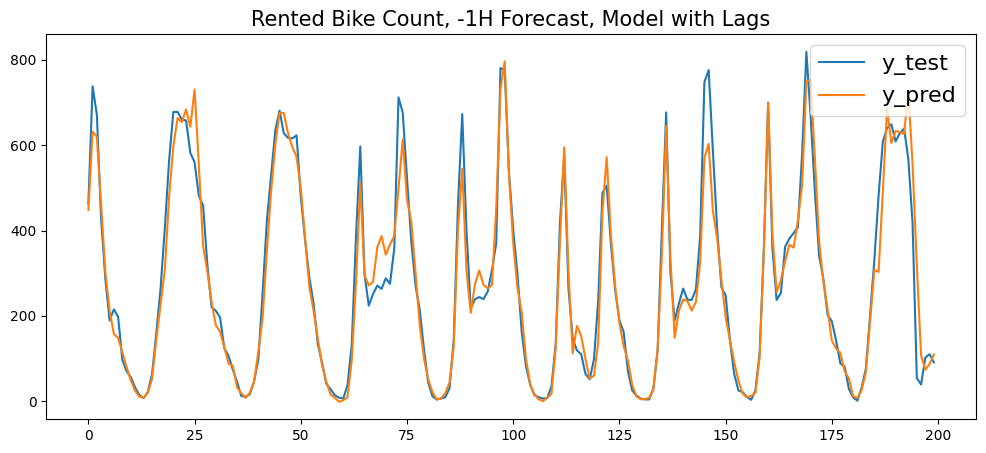

In [36]:
n = 200
plt.figure(figsize=(12, 5))
plt.plot(y_test.values[:n], label='y_test')
plt.plot(y_pred[:n], label='y_pred')
plt.legend(fontsize=16)
plt.title('Rented Bike Count, -1H Forecast, Model with Lags', fontsize=15)

In [37]:
model_lags.save_model('../data/06_models/first_catboost_model.cbm')
print("Model saved at /data/06_models/first_catboost_model.cbm")

Model saved at /data/06_models/first_catboost_model.cbm
